This tutorial will cover the basics up to predicting the 21-cm power spectrum and global signal, assuming PopII stars only (see separate tutorial for PopIII). We will start by importing the necessary packages (Zeus, numpy, class)

In [ ]:
import zeus21
from matplotlib import pyplot as plt
import numpy as np

First we set up the user parameters.

In [2]:
precisionboost = 1. # boost the precision in redshift 
zmin = 5. # min redshift down to which we compute the 21-cm related quantities
UserParams = zeus21.User_Parameters(precisionboost=precisionboost, zmin=zmin)

Now we set up the cosmology by calling zeus21.Cosmo_Parameters.

This will run CLASS, which will use the input parameters passed to zeus21.Cosmo_Parameters. 
An instance of Class will be stored as attribute to zeus21.Cosmo_Parameters.

In [3]:
# set up your parameters here, as an example the CDM (reduced) density
omega_cdm = 0.12
CosmoParams = zeus21.Cosmo_Parameters(UserParams=UserParams, omegac=omega_cdm)

We also need to generate the halo mass function at all desired z and M, which ends the cosmology part.

In [4]:
HMFinterp = zeus21.HMF_interpolator(UserParams=UserParams,CosmoParams=CosmoParams)

Then, we can set the astrophysics parameters. 

In [ ]:
# set up your parameters
# here are the peak of f*(Mh) and the escape fraction amplitude as an example
epsstar = 0.1
fesc10 = 0.1
AstroParams = zeus21.Astro_Parameters(CosmoParams=CosmoParams, epsstar=epsstar, fesc10=fesc10)

Now, we can compute the 21-cm global signal by calling zeus21.get_T21_coefficients.

This will compute multiple related quantities:
- the SFRD, the basic ingredient for zeus21 formalism,
- the Lyman-alpha properties and fluxes,
- the X-ray properties and fluxes,
- and the reionization quantities.

In [6]:
T21global = zeus21.get_T21_coefficients(UserParams=UserParams, CosmoParams=CosmoParams, AstroParams=AstroParams, HMFinterp=HMFinterp)
zlist = T21global.zintegral

The T21global instance holds all the information needed to find the 21-cm signal during cosmic dawn. It has saved the 21-cm global signal, the Wouthuysen-Field coupling, and all temperatures. It also has the effective biases $\gamma_R$ for all $R$ (which will be used for the power spectrum below). This structure also has ancillary data like the evolution of the SFRD and Nion. If you want to learn what else the CoeffStructure holds, just do dir(CoeffStructure).

Let us start by plotting the global signal.

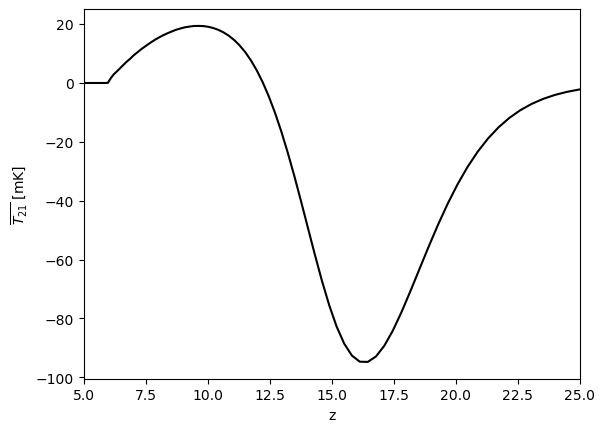

In [32]:
plt.figure()
plt.plot(zlist, T21global.T21avg, "k")
plt.xlabel(r"z");
plt.ylabel(r"$\overline{ T_{21}}$ [mK]")
plt.xlim(zmin, 25)
plt.show()

It has the usual absorption trough around $z\sim15$ (given so far we only have atomic-cooling haloes), and turns into emission at $z\sim11$.

Since the v2 version of zeus21 now properly computes reionization quantities, let us now plot the volume fraction of ionized hydrogen.

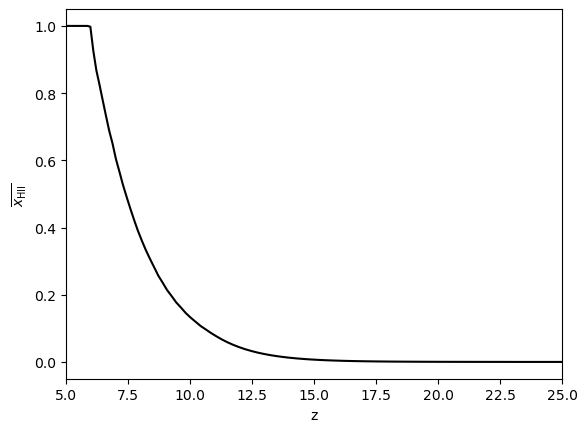

In [33]:
plt.figure()
plt.plot(zlist, 1-T21global.xHI_avg, "k")
plt.xlabel(r"z");
plt.ylabel(r"$\overline{ x_{\rm HII}}$")
plt.xlim([zmin, 25])
plt.show()

Let us plot the relevant temperatures too. Here is the CMB temperature $T_{\rm CMB}$; the gas kinetic temperature $T_k$, which has an adiabatic/cosmological and an X-ray component; and the spin temperature $T_S$, which has the WF coupling in it (and we store its inverse in the code).

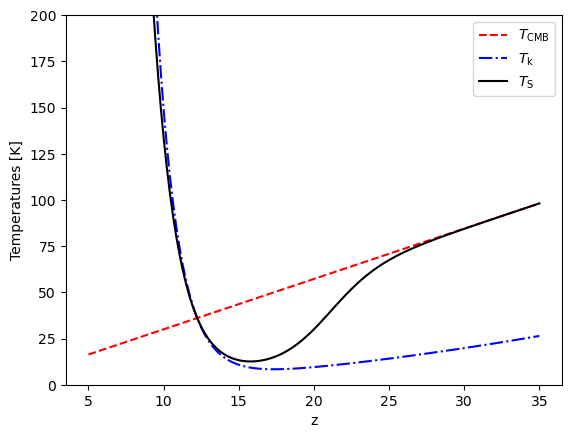

In [34]:
plt.figure()
plt.plot(zlist, T21global.T_CMB, "r--", label=r"$T_{\rm CMB}$")
plt.plot(zlist, T21global.Tk_avg, "b-.", label=r"$T_{\rm k}$")
plt.plot(zlist, 1.0/T21global._invTs_avg, "k", label=r"$T_{\rm S}$")
plt.xlabel(r"z")
plt.ylabel(r"Temperatures [K]")
plt.ylim(0, 200)
plt.legend()
plt.show()

This lines up with our expectation from the 21-cm global signal above. Absorption begins when $T_S$ departs from $T_{\rm CMB}$, at $z\sim 20$, as it begins to couple to $T_k$. It turns into emission at $z\sim 11$ when $T_S\sim T_k > T_{\rm CMB}$. Full WF coupling only occurs after there has been some X-ray heating, so we don't get a deep 21-cm trough for this model. This would be different with a lower X-ray luminosity $L_X$ as we will see below.

Let's move now to the 21-cm fluctuations.

Note that reionization is only properly computed for the global signal for now. Correlations between the reionization and other 21-cm quantities will be added in a future version of zeus21.

In [10]:
RSDMODE = 1 # which RSD mode you want, 0 is no RSDs (real space), 1 is spherical (as simulations usually take), 2 is mu~1 (outside the wedge, most relevant for observations)
PS21 = zeus21.Power_Spectra(UserParams, CosmoParams, AstroParams, T21global, RSD_MODE = RSDMODE)

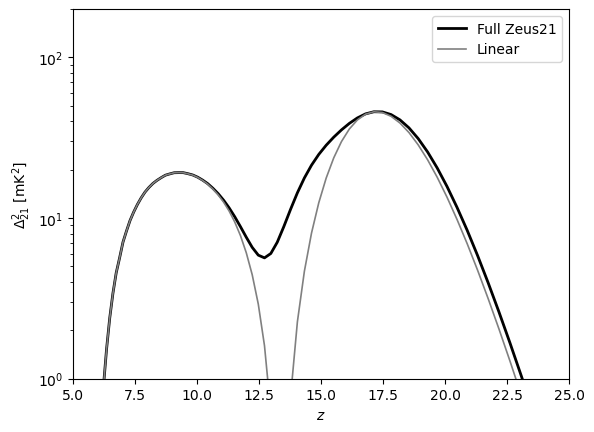

In [35]:
#choose a k to plot
klist = PS21.klist_PS
kchoose=0.3
_ik = min(range(len(klist)), key=lambda i: np.abs(klist[i]-kchoose))

plt.figure()
plt.semilogy(zlist,PS21.Deltasq_T21[:,_ik], color="k", linewidth=2.0, label="Full Zeus21")
plt.semilogy(zlist,PS21.Deltasq_T21_lin[:,_ik], color="gray", linewidth=1.2, label="Linear")

plt.xlabel(r"$z$")
plt.ylabel(r"$\Delta^2_{21}$ [mK$^2$]")
plt.legend()

plt.xlim(zmin, 25)
plt.ylim(1, 200)
plt.show()

This shows the evolution of the fluctuations at a particular scale (i.e., wavenumber $k$). We have shown the full result from zeus21, as well as the linear approximation (which is also stored). We can flip the script now and show the 21-cm power against wavenumber at a particular redshift.

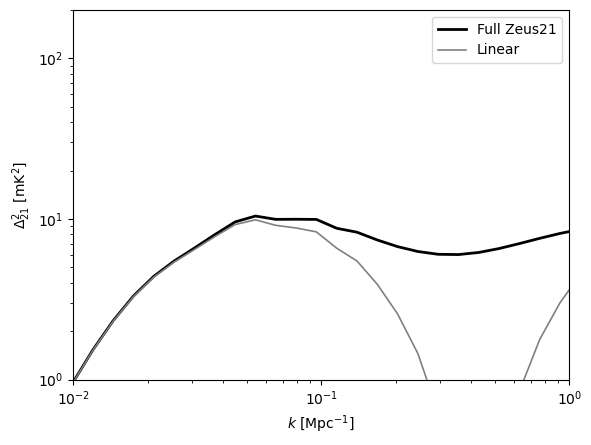

In [36]:
#choose a z to plot
zchoose=13.
_iz = min(range(len(zlist)), key=lambda i: np.abs(zlist[i]-zchoose))

plt.figure()
plt.loglog(klist,PS21.Deltasq_T21[_iz], color='k', linewidth=2.0, label="Full Zeus21")
plt.loglog(klist,PS21.Deltasq_T21_lin[_iz], color='gray', linewidth=1.2, label="Linear")

plt.xlabel(r"$k$ [Mpc$^{-1}$]")
plt.ylabel(r"$\Delta^2_{21}$ [mK$^2$]")
plt.legend()

plt.xlim(1e-2, 1)
plt.ylim(1, 200)
plt.show()

This was for a specific set of astro+cosmo parameters. Let's do a different example with lower X-ray luminosity (which we expect will produce a deeper cosmic dawn absorption). This is controlled through the free parameter L40_xray (luminosity per unit SFR in units of 10^40 erg/s/SFR), with a fiducial value of 3.0. Let's lower it to 1.0 and see what happens.

In [15]:
AstroParams_lowLX = zeus21.Astro_Parameters(CosmoParams=CosmoParams, epsstar=epsstar, L40_xray=1.0)
T21global_lowLX = zeus21.get_T21_coefficients(UserParams=UserParams, CosmoParams=CosmoParams, AstroParams=AstroParams_lowLX, HMFinterp=HMFinterp)
PS21_lowLX = zeus21.Power_Spectra(UserParams, CosmoParams, AstroParams_lowLX, T21global_lowLX, RSD_MODE = RSDMODE)

Note that we can re-run the astrophysics part only, so it should take ~few seconds in a laptop. Let's plot the global signal and fluctuations comparing with the fiducial case.

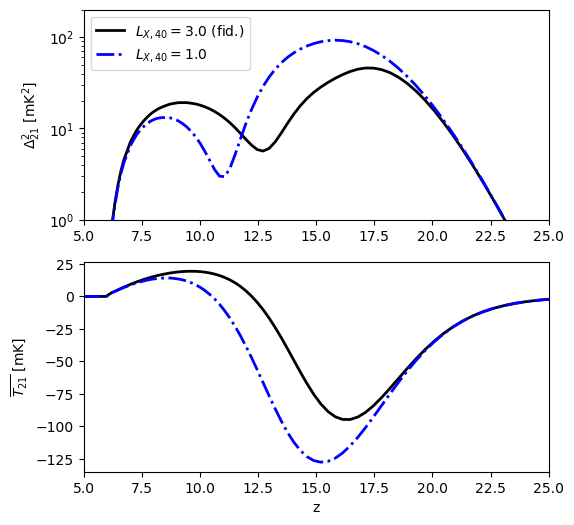

In [37]:
f = plt.figure(figsize = (6,6))

ax = f.add_subplot(211)

plt.semilogy(zlist, PS21.Deltasq_T21[:,_ik], "k", linewidth=2.0, label=r"$L_{X,40} = 3.0$ (fid.)")
plt.semilogy(zlist, PS21_lowLX.Deltasq_T21[:,_ik], "b-.", linewidth=2.0, label=r"$L_{X,40} = 1.0$")

plt.ylabel(r"$\Delta^2_{21}$ [mK$^2$]")
plt.legend()
plt.xlim(5, 25)
plt.ylim(1,200)

ax = f.add_subplot(212)

plt.plot(zlist,T21global.T21avg, "k", linewidth=2.0)
plt.plot(zlist,T21global_lowLX.T21avg, "b-.", linewidth=2.0)

plt.xlabel(r"z")
plt.ylabel(r"$\overline{ T_{21}}$ [mK]")

plt.xlim(5, 25)
plt.show()

Just as we expected! Lowering the X-ray luminosity (blue) makes for a deeper 21-cm global absorption, and larger 21-cm fluctuations too. By $z\sim 10$ there is still enough heating to raise the 21-cm signal near absorption. We can confirm this by plotting the spin temperature and comparing against the `standard' case

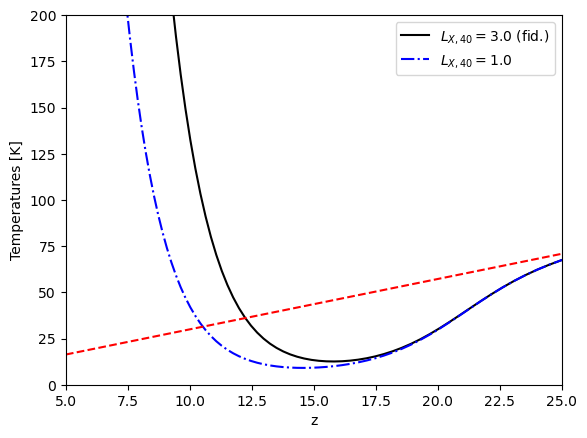

In [38]:
plt.figure()
plt.plot(zlist, 1.0/T21global._invTs_avg, "k", label=r"$L_{X,40} = 3.0$ (fid.)")
plt.plot(zlist, 1.0/T21global_lowLX._invTs_avg, "b-.", label=r"$L_{X,40} = 1.0$")
plt.plot(zlist, T21global.T_CMB, "r--")
plt.xlabel(r"z")
plt.ylabel(r"Temperatures [K]")
plt.legend()
plt.xlim(5, 25)
plt.ylim(0,200)
plt.show()

You're now ready to calculate any 21-cm power spectrum or global signal that you want!